# Proyecto de Ciencia de Datos — Tendencias de YouTube en Alemania (DE)
### Metodología CRISP-DM | Curso 1ACC0216 - Fundamentos de Data Science | UPC 2026-1

**Grupo:** [N° de grupo] — **Sección:** [sección]
**Integrantes:** [nombre 1], [nombre 2], [nombre 3], [nombre 4], [nombre 5]
**País asignado:** Alemania (DE)


In [ ]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 110

BLUE = "#1A6BB5"
ORANGE = "#E8760A"


## 1. Comprensión del negocio

**Objetivo del negocio:** una consultora internacional necesita entender las tendencias de videos de YouTube en Alemania para responder a los requerimientos de información de un cliente de marketing digital (categorías, canales, tiempo, geografía y factibilidad predictiva).

**Objetivo de Data Science:** modelar y explicar el comportamiento de las variables de interacción (vistas, likes, dislikes, comentarios) de los videos en tendencia en Alemania.

- **Variable dependiente:** `views` (número de vistas). Se eligió porque es la métrica de mayor interés comercial (alcance) y la que presenta mayor variabilidad explicable a partir del resto de señales de interacción.
- **Variables independientes principales:**
  - `likes`, `dislikes`, `comment_count` (interacción directa del público)
  - `category_name` (categoría del video)
  - `days_to_trend` (variable derivada: días transcurridos entre publicación y aparición en tendencia)
  - `like_dislike_ratio`, `views_comment_ratio` (variables derivadas usadas en el análisis exploratorio)


## 2. Comprensión de los datos

### 2.1 Cargar los datos

In [ ]:
df_raw = pd.read_csv("DEvideos_cc50_202101.csv")

with open("DE_category_id.json", encoding="utf-8") as f:
    cats_json = json.load(f)
catmap = {int(i["id"]): i["snippet"]["title"] for i in cats_json["items"]}
catmap[29] = "Nonprofits & Activism"  # categoria estandar de YouTube ausente en el JSON de DE

df = df_raw.copy()
df["category_name"] = df["category_id"].map(catmap)
df.head()


,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,...,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,state,lat,lon,geometry,category_name
0,LgVi6y5QIjM,17.14.11,Sing zu Ende! | Gesangseinlagen vom Feinsten |...,inscope21,24,2017-11-13T17:08:49.000Z,"inscope21|""sing zu ende""|""gesangseinlagen""|""ge...",252786,35885,230,...,https://i.ytimg.com/vi/LgVi6y5QIjM/default.jpg,False,False,False,Heute gibt es mal wieder ein neues Format... w...,Schleswig Holstein,54.783748,9.433315,POINT (9.433315388 54.78374778),Entertainment
1,Bayt7uQith4,17.14.11,Kinder ferngesteuert im Kiosk! Erwachsene abzo...,LUKE! Die Woche und ich,23,2017-11-12T22:30:01.000Z,"Kinder|""ferngesteuert""|""Kinder ferngesteuert""|...",797196,53576,302,...,https://i.ytimg.com/vi/Bayt7uQith4/default.jpg,False,False,False,Kinder ferngesteuert! Kinder lassen sich sooo ...,Nordrhein Westfalen,52.029988,8.530011,POINT (8.530011351000001 52.02998822),Comedy
2,1ZAPwfrtAFY,17.14.11,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,2017-11-13T07:30:00.000Z,"last week tonight trump presidency|""last week ...",2418783,97190,6146,...,https://i.ytimg.com/vi/1ZAPwfrtAFY/default.jpg,False,False,False,"One year after the presidential election, John...",Saarland,49.250390,6.970003,POINT (6.970003213 49.25039044),Entertainment
3,AHtypnRk7JE,17.14.11,Das Fermi-Paradoxon,100SekundenPhysik,27,2017-11-12T15:00:01.000Z,"Physik|""Wissenschaft""|""Technik""|""Science-Ficti...",380247,31821,458,...,https://i.ytimg.com/vi/AHtypnRk7JE/default.jpg,False,False,False,►Alle Videos: http://bit.ly/1fa7Tw3\n\n\n✚Snap...,Bayern,50.266607,10.966607,POINT (10.96660681 50.26660748),Education
4,ZJ9We4bjcg0,17.14.11,18 SONGS mit Kelly MissesVlog (Sing-off),rezo,24,2017-11-12T13:10:36.000Z,"kelly|""missesvlog""|""kelly song""|""bausa""|""bausa...",822213,100684,2467,...,https://i.ytimg.com/vi/ZJ9We4bjcg0/default.jpg,False,False,False,18 Song Mashup über den (veränderten) Beat von...,Berlin,52.521819,13.401549,POINT (13.40154862 52.52181866),Entertainment


### 2.2 Descripción de los datos

In [ ]:
print("Filas x columnas:", df.shape)
df.dtypes


Filas x columnas: (40840, 21)


video_id                      str
trending_date                 str
title                         str
channel_title                 str
category_id                 int64
publish_time                  str
tags                          str
views                       int64
likes                       int64
dislikes                    int64
comment_count               int64
thumbnail_link                str
comments_disabled            bool
ratings_disabled             bool
video_error_or_removed       bool
description                   str
state                         str
lat                       float64
lon                       float64
geometry                      str
category_name                 str
dtype: object

In [ ]:
df.isnull().sum()


video_id                     0
trending_date                0
title                        0
channel_title                0
category_id                  0
publish_time                 0
tags                         0
views                        0
likes                        0
dislikes                     0
comment_count                0
thumbnail_link               0
comments_disabled            0
ratings_disabled             0
video_error_or_removed       0
description               1552
state                        0
lat                          0
lon                          0
geometry                     0
category_name                0
dtype: int64

In [ ]:
print("Duplicados exactos:", df.duplicated().sum())
print("Duplicados por video_id + trending_date:", df.duplicated(subset=["video_id","trending_date"]).sum())
print("N° de estados:", df['state'].nunique())
print("N° de categorías:", df['category_id'].nunique())


Duplicados exactos: 0
Duplicados por video_id + trending_date: 0
N° de estados: 16
N° de categorías: 18


**Hallazgos:**
- 40,840 registros (video x día en tendencia), 20 columnas originales.
- La única columna con nulos es `description` (1,552 vacíos, ~3.8%), campo de texto libre no usado en el modelado.
- No hay duplicados exactos ni duplicados por combinación video-día.
- 16 estados alemanes representados; 18 categorías de video presentes en el dataset, una de ellas (id 29, *Nonprofits & Activism*) no estaba documentada en el JSON de categorías y se completó manualmente con el catálogo estándar de YouTube.


### 2.3 Exploración de los datos

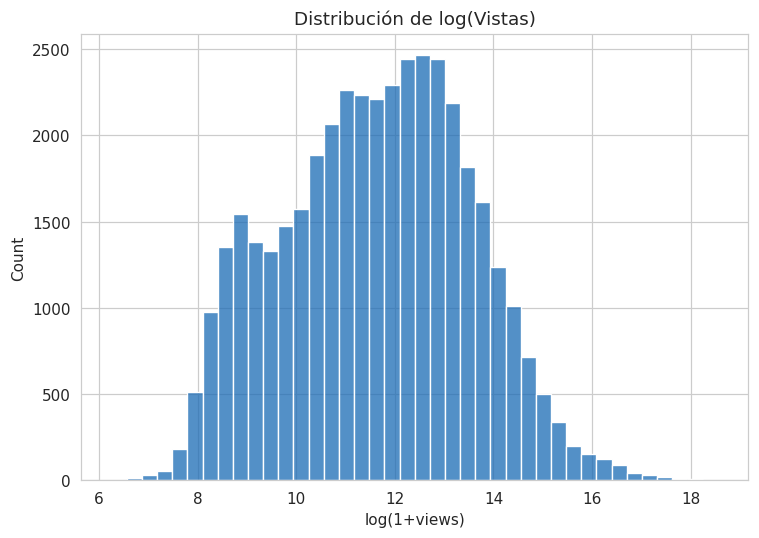

In [ ]:
fig, ax = plt.subplots(figsize=(7,5))
sns.histplot(np.log1p(df["views"]), bins=40, color=BLUE, ax=ax)
ax.set_title("Distribución de log(Vistas)")
ax.set_xlabel("log(1+views)")
plt.tight_layout(); plt.show()


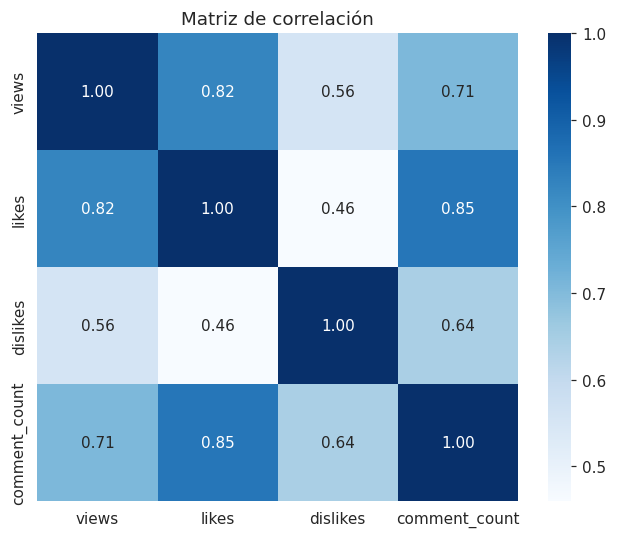

In [ ]:
corr = df[["views","likes","dislikes","comment_count"]].corr()
fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="Blues", fmt=".2f", ax=ax)
ax.set_title("Matriz de correlación")
plt.tight_layout(); plt.show()


**Hallazgos:** la distribución de vistas es fuertemente asimétrica (long tail), típica de contenido viral; se recomienda trabajar en escala logarítmica para el modelado. Existe alta correlación entre `likes`, `comment_count` y `views` (>0.7), lo que sugiere que la interacción del público es un buen predictor de las vistas.

### 2.4 Verificar la calidad de los datos

In [ ]:
def iqr_bounds(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - 1.5*iqr, q3 + 1.5*iqr

low, high = iqr_bounds(df["views"])
n_outliers = ((df["views"] < low) | (df["views"] > high)).sum()
print(f"Outliers en 'views' (regla IQR): {n_outliers} ({n_outliers/len(df)*100:.1f}%)")


Outliers en 'views' (regla IQR): 4742 (11.6%)


Los "outliers" detectados corresponden mayormente a videos genuinamente virales (picos reales de vistas), por lo que **no se eliminan**: se documentan y se maneja la asimetría mediante transformación logarítmica en la etapa de modelado.

## 3. Preparación de los datos

### 3.1 Limpieza y transformación de fechas

In [ ]:
df["trending_date"] = pd.to_datetime(df["trending_date"], format="%y.%d.%m")
df["publish_time"] = pd.to_datetime(df["publish_time"])
df["publish_date"] = pd.to_datetime(df["publish_time"].dt.date)
df.head(2)


,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,...,comments_disabled,ratings_disabled,video_error_or_removed,description,state,lat,lon,geometry,category_name,publish_date
0,LgVi6y5QIjM,2017-11-14,Sing zu Ende! | Gesangseinlagen vom Feinsten |...,inscope21,24,2017-11-13 17:08:49+00:00,"inscope21|""sing zu ende""|""gesangseinlagen""|""ge...",252786,35885,230,...,False,False,False,Heute gibt es mal wieder ein neues Format... w...,Schleswig Holstein,54.783748,9.433315,POINT (9.433315388 54.78374778),Entertainment,2017-11-13
1,Bayt7uQith4,2017-11-14,Kinder ferngesteuert im Kiosk! Erwachsene abzo...,LUKE! Die Woche und ich,23,2017-11-12 22:30:01+00:00,"Kinder|""ferngesteuert""|""Kinder ferngesteuert""|...",797196,53576,302,...,False,False,False,Kinder ferngesteuert! Kinder lassen sich sooo ...,Nordrhein Westfalen,52.029988,8.530011,POINT (8.530011351000001 52.02998822),Comedy,2017-11-12


### 3.2 Construcción de nuevas variables (feature engineering)

In [ ]:
df["days_to_trend"] = (df["trending_date"] - df["publish_date"]).dt.days
df.loc[df["days_to_trend"] < 0, "days_to_trend"] = np.nan

df["like_dislike_ratio"] = df["likes"] / df["dislikes"].replace(0, np.nan)
df["views_comment_ratio"] = df["views"] / df["comment_count"].replace(0, np.nan)
df["like_rate"] = df["likes"] / df["views"]
df["engagement_rate"] = (df["likes"] + df["dislikes"] + df["comment_count"]) / df["views"]

df["description"] = df["description"].fillna("(sin descripcion)")
df.head(2)


,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,...,lat,lon,geometry,category_name,publish_date,days_to_trend,like_dislike_ratio,views_comment_ratio,like_rate,engagement_rate
0,LgVi6y5QIjM,2017-11-14,Sing zu Ende! | Gesangseinlagen vom Feinsten |...,inscope21,24,2017-11-13 17:08:49+00:00,"inscope21|""sing zu ende""|""gesangseinlagen""|""ge...",252786,35885,230,...,54.783748,9.433315,POINT (9.433315388 54.78374778),Entertainment,2017-11-13,1.0,156.021739,164.253411,0.141958,0.148956
1,Bayt7uQith4,2017-11-14,Kinder ferngesteuert im Kiosk! Erwachsene abzo...,LUKE! Die Woche und ich,23,2017-11-12 22:30:01+00:00,"Kinder|""ferngesteuert""|""Kinder ferngesteuert""|...",797196,53576,302,...,52.029988,8.530011,POINT (8.530011351000001 52.02998822),Comedy,2017-11-12,2.0,177.403974,623.784038,0.067206,0.069188


### 3.3 Dataset limpio final

In [ ]:
df_clean = df.drop(columns=["thumbnail_link", "geometry"])
df_clean.to_csv("DEvideos_clean.csv", index=False)

# vista por video unico (evita sobre-conteo, cada video aparece varios dias en tendencia)
df_unique = df_clean.sort_values("trending_date").drop_duplicates(subset="video_id", keep="last")
print("Registros (video x dia):", df_clean.shape[0], " | Videos unicos:", df_unique.shape[0])


Registros (video x dia): 40840  | Videos unicos: 29627


## 4. Requerimientos del cliente

A continuación se responde cada requerimiento solicitado, acompañado de su visualización correspondiente.

### R1. ¿Qué categorías de videos son las de mayor tendencia?

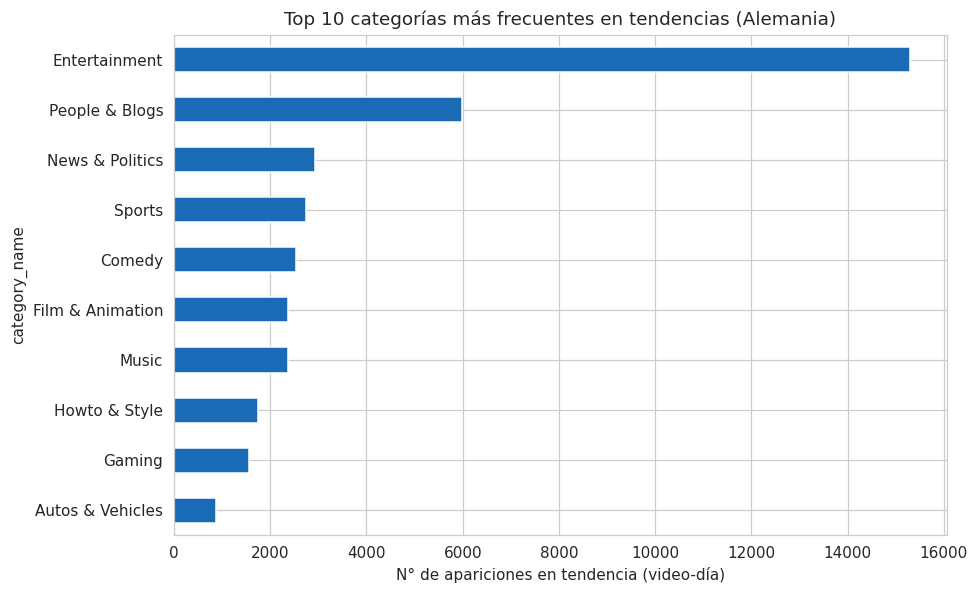

category_name
Entertainment       15292
People & Blogs       5988
News & Politics      2935
Sports               2752
Comedy               2534
Film & Animation     2376
Music                2372
Howto & Style        1745
Gaming               1565
Autos & Vehicles      873
Name: count, dtype: int64

In [ ]:
r1 = df_clean["category_name"].value_counts()
fig, ax = plt.subplots(figsize=(9,5.5))
r1.head(10).sort_values().plot(kind="barh", color=BLUE, ax=ax)
ax.set_title("Top 10 categorías más frecuentes en tendencias (Alemania)")
ax.set_xlabel("N° de apariciones en tendencia (video-día)")
plt.tight_layout(); plt.show()
r1.head(10)


**Respuesta:** *Entertainment*, *People & Blogs* y *News & Politics* concentran la mayor cantidad de apariciones en tendencia en Alemania.

### R2. ¿Qué categorías de videos son las que más gustan? ¿Y las que menos gustan?

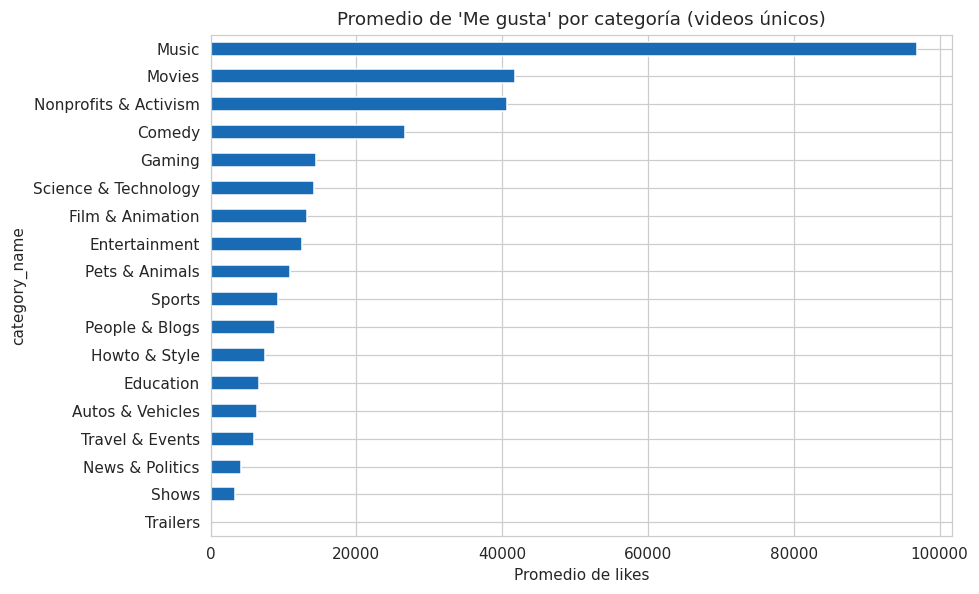

category_name
Music                    96882.184593
Movies                   41807.000000
Nonprofits & Activism    40655.623762
Comedy                   26700.754997
Gaming                   14419.908173
Science & Technology     14165.792890
Film & Animation         13286.483262
Entertainment            12471.969015
Pets & Animals           10843.794118
Sports                    9289.157341
People & Blogs            8800.677542
Howto & Style             7502.895004
Education                 6634.332326
Autos & Vehicles          6296.922619
Travel & Events           5974.215517
News & Politics           4178.724356
Shows                     3402.184466
Trailers                     0.000000
Name: likes, dtype: float64

In [ ]:
r2 = df_unique.groupby("category_name")["likes"].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9,5.5))
r2.sort_values().plot(kind="barh", color=BLUE, ax=ax)
ax.set_title("Promedio de 'Me gusta' por categoría (videos únicos)")
ax.set_xlabel("Promedio de likes")
plt.tight_layout(); plt.show()
r2


**Respuesta:** *Music*, *Movies* y *Nonprofits & Activism* son las categorías con mayor promedio de likes por video; *Trailers*, *Shows* y *News & Politics* son las que menos gustan en promedio.

### R3. ¿Qué categorías tienen la mejor proporción (ratio) Me gusta/No me gusta?

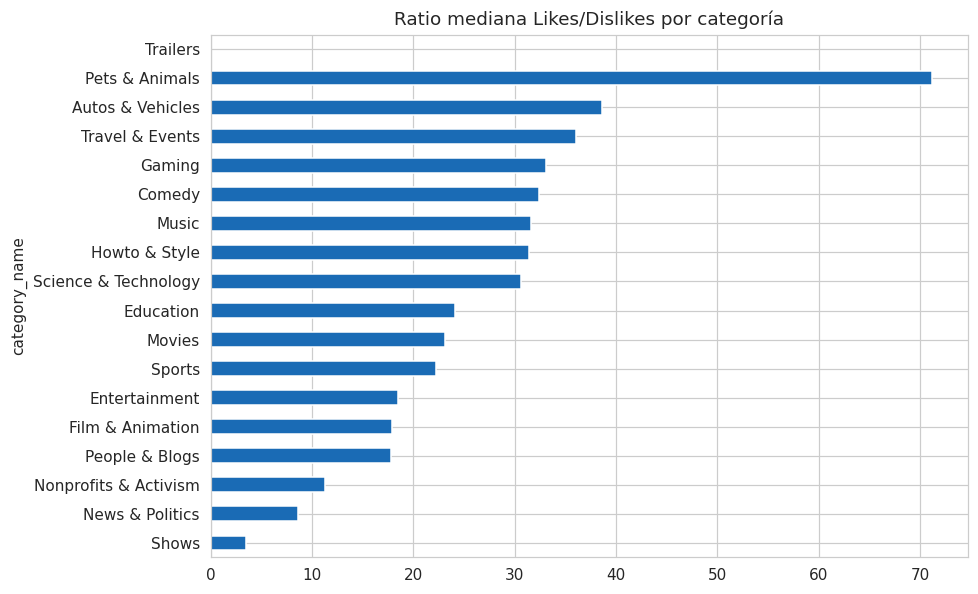

category_name
Pets & Animals           71.153623
Autos & Vehicles         38.625000
Travel & Events          36.000000
Gaming                   33.086830
Comedy                   32.369318
Music                    31.571023
Howto & Style            31.381516
Science & Technology     30.605326
Education                24.076508
Movies                   23.085036
Sports                   22.200000
Entertainment            18.468085
Film & Animation         17.909091
People & Blogs           17.785995
Nonprofits & Activism    11.263158
News & Politics           8.602469
Shows                     3.451485
Trailers                       NaN
Name: like_dislike_ratio, dtype: float64

In [ ]:
r3 = df_unique.groupby("category_name")["like_dislike_ratio"].median().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9,5.5))
r3.sort_values().plot(kind="barh", color=BLUE, ax=ax)
ax.set_title("Ratio mediana Likes/Dislikes por categoría")
plt.tight_layout(); plt.show()
r3


**Respuesta:** *Pets & Animals*, *Autos & Vehicles* y *Travel & Events* muestran la mejor proporción likes/dislikes; son categorías de contenido poco polarizante.

### R4. ¿Qué categorías tienen la mejor proporción (ratio) Vistas/Comentarios?

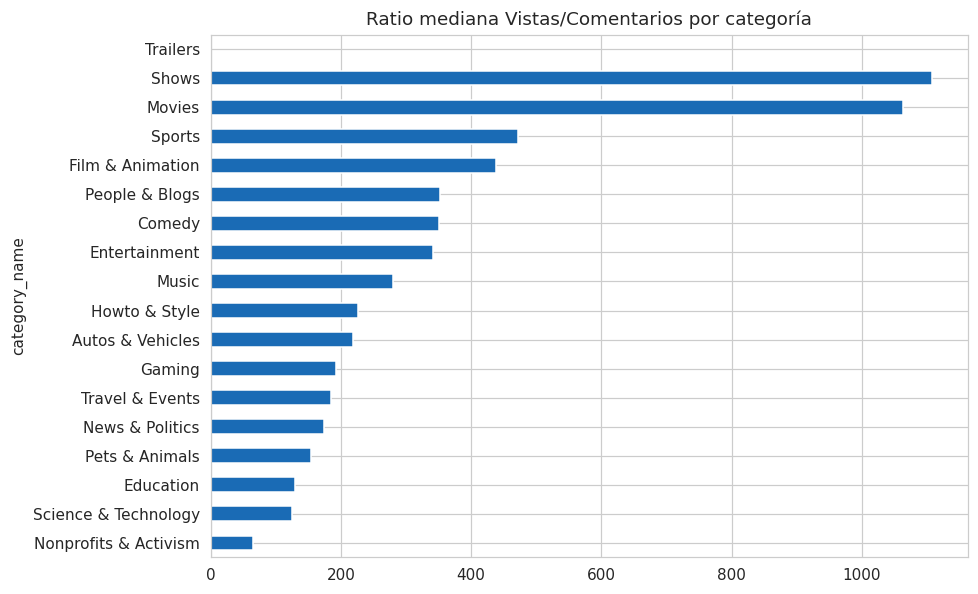

category_name
Shows                    1107.783240
Movies                   1063.180214
Sports                    471.916416
Film & Animation          437.971292
People & Blogs            352.746515
Comedy                    350.099738
Entertainment             342.264048
Music                     279.695553
Howto & Style             225.560000
Autos & Vehicles          219.221852
Gaming                    191.874430
Travel & Events           185.068059
News & Politics           173.932893
Pets & Animals            154.356774
Education                 129.379310
Science & Technology      125.153704
Nonprofits & Activism      64.817300
Trailers                         NaN
Name: views_comment_ratio, dtype: float64

In [ ]:
r4 = df_unique.groupby("category_name")["views_comment_ratio"].median().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9,5.5))
r4.sort_values().plot(kind="barh", color=BLUE, ax=ax)
ax.set_title("Ratio mediana Vistas/Comentarios por categoría")
plt.tight_layout(); plt.show()
r4


**Respuesta:** *Shows* y *Movies* tienen la mayor cantidad de vistas por cada comentario (baja tasa de comentarios relativa), mientras que categorías más conversacionales como *Comedy* o *People & Blogs* generan más comentarios por vista.

### R5. ¿Cómo ha cambiado el volumen de videos en tendencia a lo largo del tiempo?

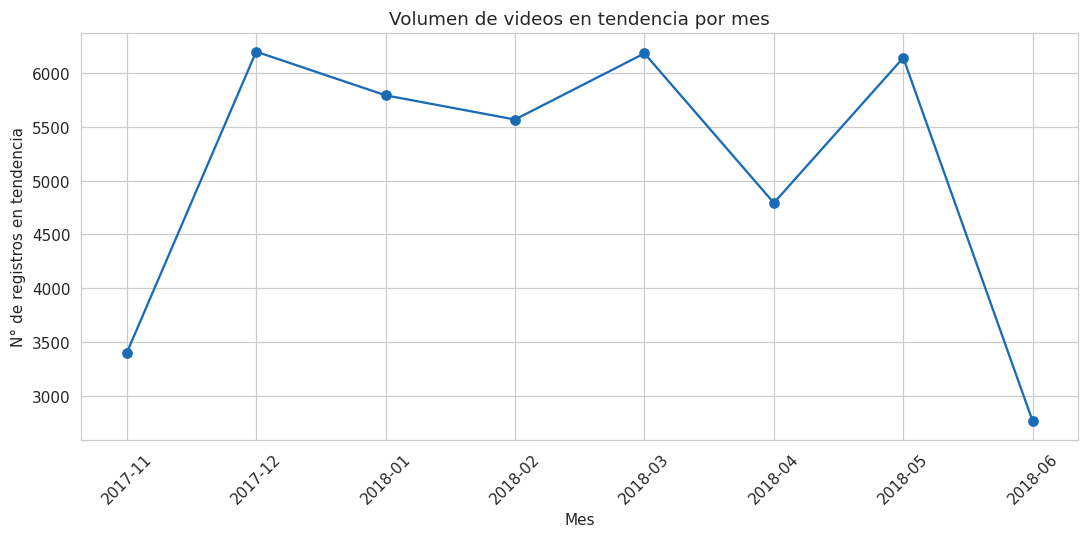

trending_date
2017-11    3399
2017-12    6199
2018-01    5793
2018-02    5568
2018-03    6183
2018-04    4793
2018-05    6142
2018-06    2763
Freq: M, dtype: int64

In [ ]:
r5 = df_clean.groupby(df_clean["trending_date"].dt.to_period("M")).size()
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(r5.index.astype(str), r5.values, marker="o", color=BLUE)
ax.set_title("Volumen de videos en tendencia por mes")
ax.set_xlabel("Mes"); ax.set_ylabel("N° de registros en tendencia")
plt.xticks(rotation=45); plt.tight_layout(); plt.show()
r5


**Respuesta:** el dataset cubre de noviembre 2017 a junio 2018; el volumen mensual de registros es relativamente estable, con variaciones asociadas a la cantidad de días capturados por mes.

### R6. ¿Qué canales son tendencia con mayor y con menor frecuencia?

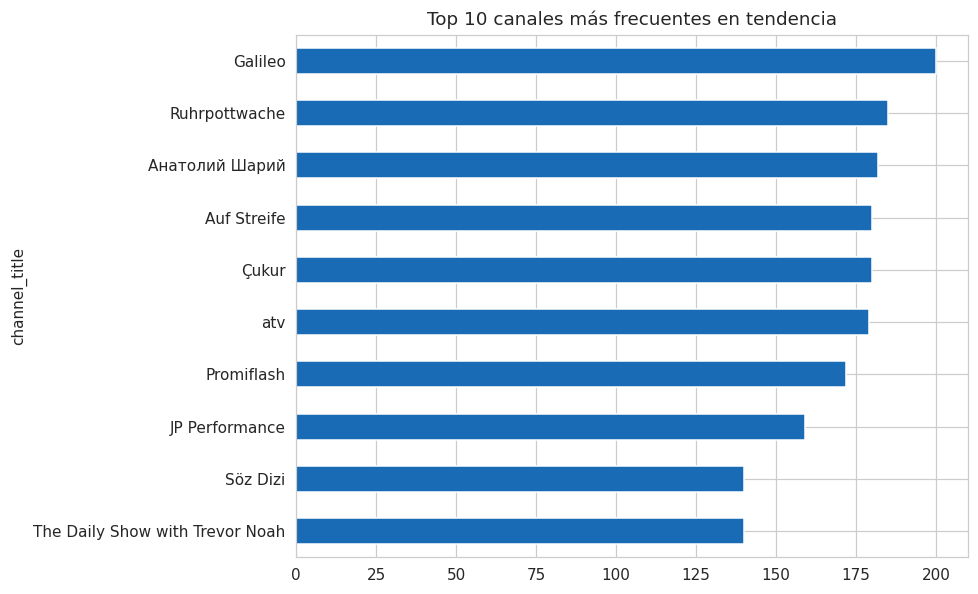

Top 10:
 channel_title
Galileo                            200
Ruhrpottwache                      185
Анатолий Шарий                     182
Çukur                              180
Auf Streife                        180
atv                                179
Promiflash                         172
JP Performance                     159
Söz Dizi                           140
The Daily Show with Trevor Noah    140
Name: count, dtype: int64

Canales con una sola aparición: 2485


In [ ]:
r6 = df_clean["channel_title"].value_counts()
fig, ax = plt.subplots(figsize=(9,5.5))
r6.head(10).sort_values().plot(kind="barh", color=BLUE, ax=ax)
ax.set_title("Top 10 canales más frecuentes en tendencia")
plt.tight_layout(); plt.show()
print("Top 10:\n", r6.head(10))
print("\nCanales con una sola aparición:", (r6==1).sum())


**Respuesta:** canales como *Galileo*, *Ruhrpottwache* y *Auf Streife* son los más recurrentes en tendencias; un número considerable de canales aparece una sola vez en todo el periodo.

### R7. ¿En qué estados se presenta el mayor número de vistas, likes y dislikes?

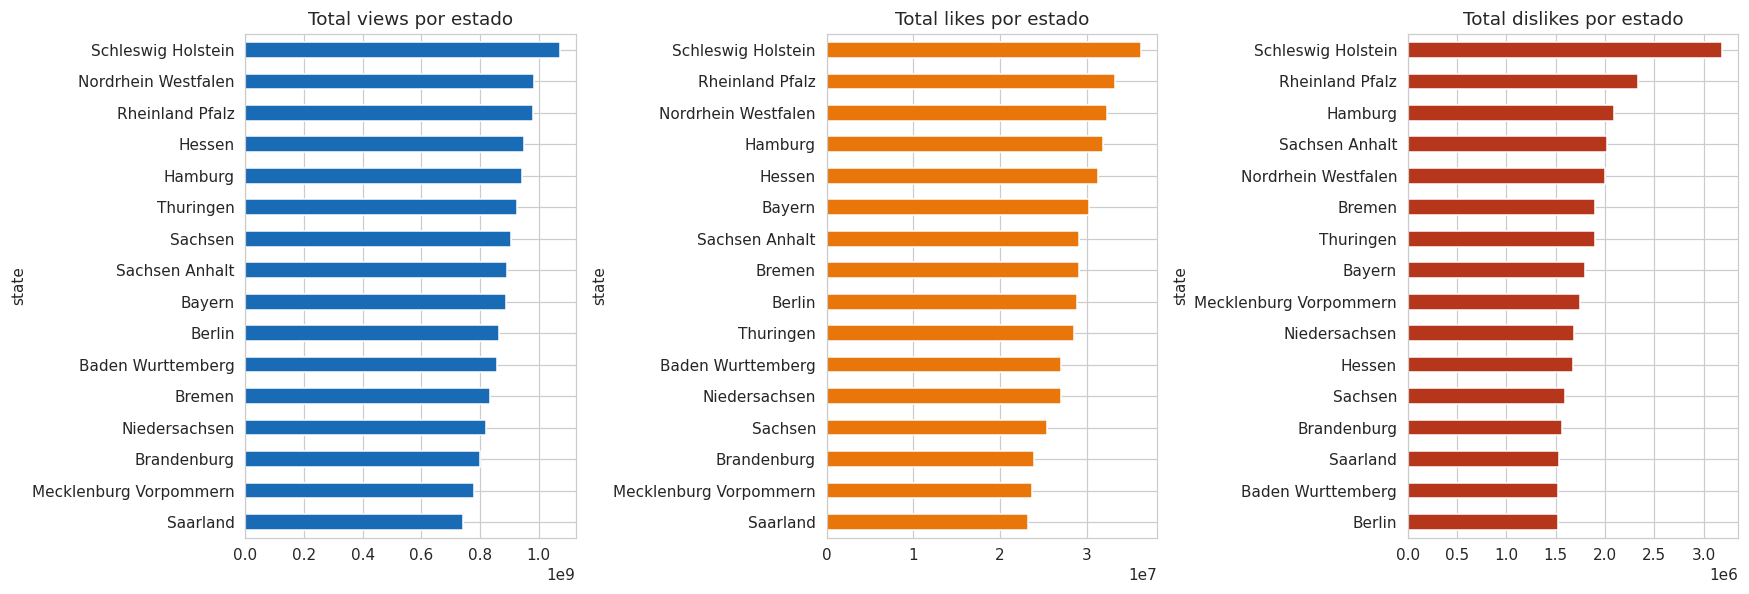

,views,likes,dislikes
state,,,
Schleswig Holstein,1072294368,36275600,3188849
Nordrhein Westfalen,982697928,32367753,2003984
Rheinland Pfalz,981393956,33228256,2334029
Hessen,950006095,31279620,1677105
Hamburg,941779585,31894567,2087936


In [ ]:
r7 = df_unique.groupby("state")[["views","likes","dislikes"]].sum().sort_values("views", ascending=False)
fig, axes = plt.subplots(1,3, figsize=(16,5.5))
for ax, col, color in zip(axes, ["views","likes","dislikes"], [BLUE, ORANGE, "#B5361A"]):
    r7[col].sort_values().plot(kind="barh", ax=ax, color=color)
    ax.set_title(f"Total {col} por estado")
plt.tight_layout(); plt.show()
r7.head()


**Respuesta:** dado que el campo `state` fue incorporado de forma aleatoria (no representa la ubicación real del espectador), los totales están relativamente distribuidos entre los 16 estados; *Schleswig Holstein*, *Nordrhein Westfalen* y *Rheinland Pfalz* encabezan la lista, aunque esta lectura debe tomarse como referencial y no como un patrón geográfico real (ver limitaciones).

### R8. ¿Los videos en tendencia son los que mayor cantidad de comentarios positivos reciben?

Correlación días en tendencia vs comentarios: 0.171
Correlación días en tendencia vs like_rate: 0.176


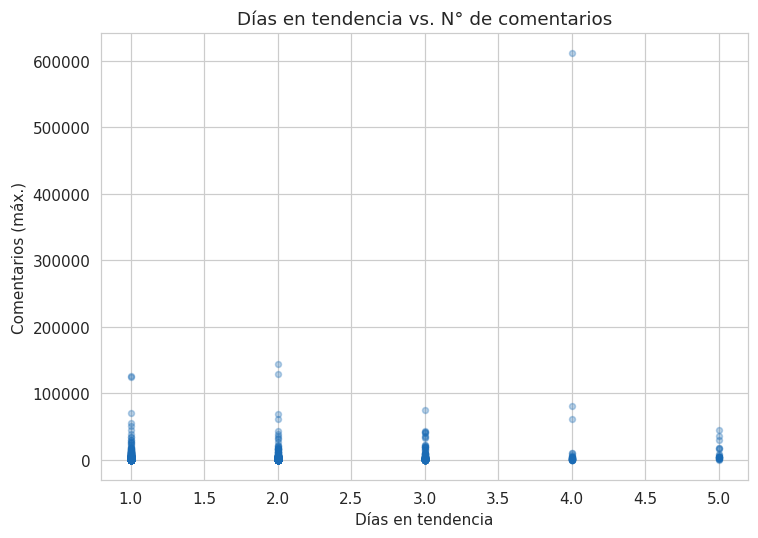

In [ ]:
r8_freq = df_clean.groupby("video_id").agg(
    dias_en_tendencia=("trending_date","count"),
    comment_count=("comment_count","max"),
    like_rate=("like_rate","max")
).reset_index()

corr_days_comments = r8_freq["dias_en_tendencia"].corr(r8_freq["comment_count"])
corr_days_likerate = r8_freq["dias_en_tendencia"].corr(r8_freq["like_rate"])
print("Correlación días en tendencia vs comentarios:", round(corr_days_comments,3))
print("Correlación días en tendencia vs like_rate:", round(corr_days_likerate,3))

fig, ax = plt.subplots(figsize=(7,5))
sample = r8_freq.sample(min(3000,len(r8_freq)), random_state=42)
ax.scatter(sample["dias_en_tendencia"], sample["comment_count"], alpha=0.3, color=BLUE, s=15)
ax.set_xlabel("Días en tendencia"); ax.set_ylabel("Comentarios (máx.)")
ax.set_title("Días en tendencia vs. N° de comentarios")
plt.tight_layout(); plt.show()


**Respuesta:** el dataset no contiene el **texto** de los comentarios, por lo que no es posible medir sentimiento real; se usó como proxy la tasa de likes (`like_rate`) y el volumen de comentarios. La correlación entre días en tendencia y cantidad de comentarios es **baja (~0.17)**, por lo que **no se puede afirmar** que los videos que permanecen más tiempo en tendencia sean los que reciben más comentarios "positivos" — permanecer en tendencia depende de más factores (categoría, canal, momento de publicación) que solo el comentario del público.

### R9. ¿Es factible predecir el número de vistas?

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

model_df = df_unique.copy()
model_df = model_df[model_df["days_to_trend"].notna() & (model_df["days_to_trend"]>=0) & (model_df["days_to_trend"]<60)]

model_df["log_views"] = np.log1p(model_df["views"])
model_df["log_likes"] = np.log1p(model_df["likes"])
model_df["log_dislikes"] = np.log1p(model_df["dislikes"])
model_df["log_comments"] = np.log1p(model_df["comment_count"])

features_num = ["log_likes","log_dislikes","log_comments","days_to_trend"]
features_cat = ["category_name"]
target = "log_views"

X = model_df[features_num+features_cat]
y = model_df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
pre = ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore"), features_cat)], remainder="passthrough")

lin_pipe = Pipeline([("pre", pre), ("model", LinearRegression())])
lin_pipe.fit(X_train, y_train)
pred_lin = lin_pipe.predict(X_test)

rf_pipe = Pipeline([("pre", pre), ("model", RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1))])
rf_pipe.fit(X_train, y_train)
pred_rf = rf_pipe.predict(X_test)

for name, pred in [("Regresión Lineal", pred_lin), ("Random Forest", pred_rf)]:
    print(name, "-> R2:", round(r2_score(y_test,pred),3),
          " MAE(log):", round(mean_absolute_error(y_test,pred),3),
          " RMSE(log):", round(mean_squared_error(y_test,pred)**0.5,3))


Regresión Lineal -> R2: 0.767  MAE(log): 0.686  RMSE(log): 0.919
Random Forest -> R2: 0.865  MAE(log): 0.519  RMSE(log): 0.699


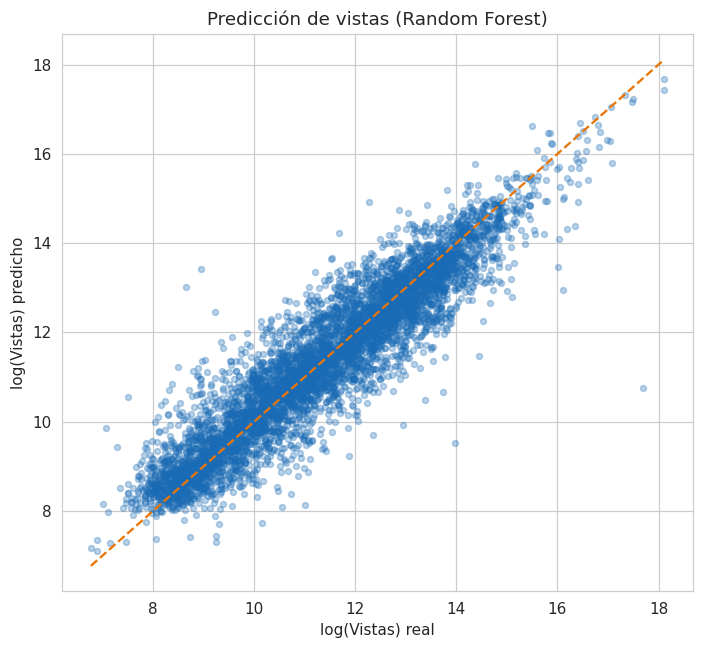

In [ ]:
fig, ax = plt.subplots(figsize=(6.5,6))
ax.scatter(y_test, pred_rf, alpha=0.3, s=15, color=BLUE)
lims = [min(y_test.min(),pred_rf.min()), max(y_test.max(),pred_rf.max())]
ax.plot(lims, lims, color=ORANGE, linestyle="--")
ax.set_xlabel("log(Vistas) real"); ax.set_ylabel("log(Vistas) predicho")
ax.set_title("Predicción de vistas (Random Forest)")
plt.tight_layout(); plt.show()


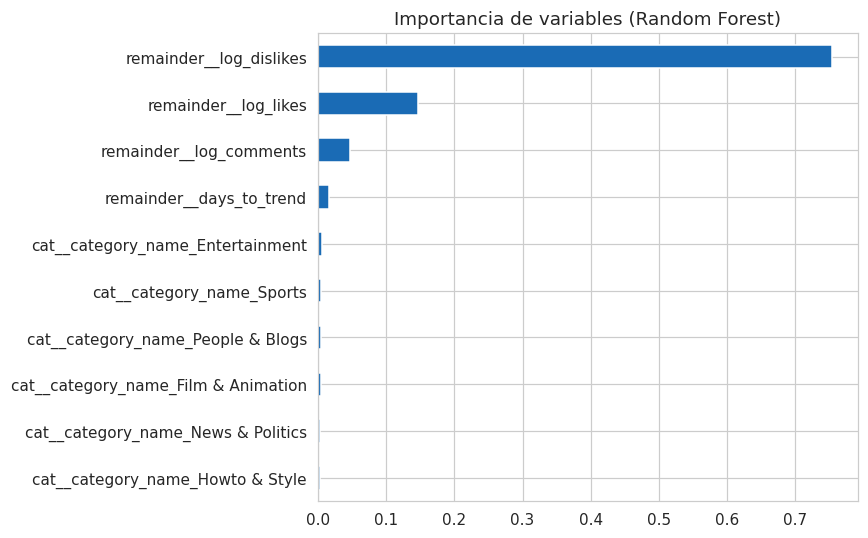

In [ ]:
importances = rf_pipe.named_steps["model"].feature_importances_
feat_names = rf_pipe.named_steps["pre"].get_feature_names_out()
imp_series = pd.Series(importances, index=feat_names).sort_values(ascending=False).head(10)
fig, ax = plt.subplots(figsize=(8,5))
imp_series.sort_values().plot(kind="barh", color=BLUE, ax=ax)
ax.set_title("Importancia de variables (Random Forest)")
plt.tight_layout(); plt.show()


**Respuesta:** sí es factible. El modelo Random Forest explica cerca del **86% de la varianza** de log(vistas) (R² ≈ 0.86) en el conjunto de prueba, superando a la regresión lineal (R² ≈ 0.77). Los `likes` y `comment_count` son las variables más determinantes, lo que confirma que la interacción del público es la señal más fuerte para estimar el alcance de un video.

## 5. Modelado y evaluación de resultados (resumen)

- **Técnica seleccionada:** regresión (Regresión Lineal como línea base y Random Forest Regressor como modelo principal), dado que el objetivo es predecir una variable numérica continua (`views`).
- **Plan de prueba:** partición 80/20 (train/test) con semilla fija para reproducibilidad.
- **Evaluación:** R², MAE y RMSE en escala logarítmica (para no penalizar en exceso los valores extremos de videos virales).
- **Resultado:** Random Forest obtiene mejor desempeño (R² ≈ 0.86) que la Regresión Lineal (R² ≈ 0.77), indicando relaciones no lineales entre las variables de interacción y las vistas.
